In [60]:
import time
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
import cv2
import time


import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

from IPython.display import clear_output
import matplotlib.colors as mcolors
from scipy.ndimage import label
from skimage.segmentation import watershed
from torchvision.utils import make_grid

from Ellipses import *
from plottings import *
from metrics import *
from GRU import *

from load_dataset import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parte 0

In [2]:
ellipses_sim = EllipsesSimulator(128, 5, 10)
frames, ground_truth = ellipses_sim.simulate(30)
frames_with_bboxes = visualize_ground_truth(frames, ground_truth)

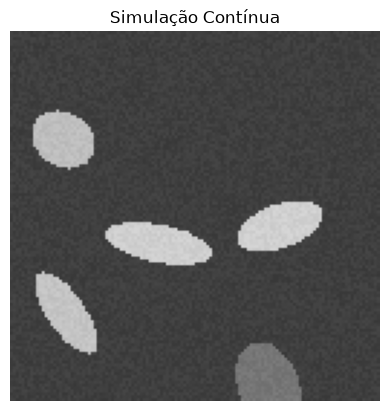

In [3]:
plot_simulation_frames(frames)

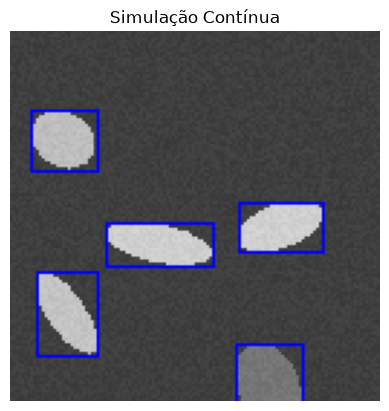

In [4]:
plot_simulation_frames(frames_with_bboxes)

In [5]:
frames_with_noisy_bboxes, noisy_annotations = create_noisy_bboxes(frames, ground_truth, 0.1)

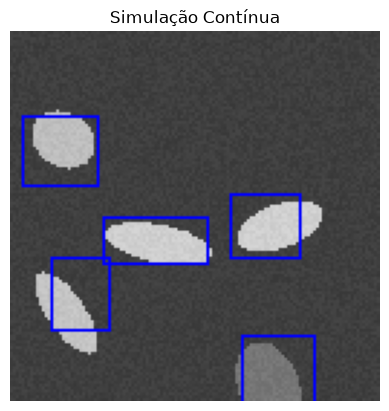

In [6]:
plot_simulation_frames(frames_with_noisy_bboxes)

In [7]:
print("Prints: (IDF1, Switches)")

# Caso (a)
print("IDF1 com predição = ground truth: ", compute_idf1(ground_truth, ground_truth))

# Caso (b)
preds_b = []
frame_k = 23

for linha in ground_truth:
    parts = linha.split(',')
    f = int(float(parts[0]))
    obj_id = int(float(parts[1]))
    
    # A partir do frame k, cruza as identidades 1 e 2
    if f >= frame_k:
        if obj_id == 1:
            parts[1] = '2'
        elif obj_id == 2:
            parts[1] = '1'
            
    preds_b.append(','.join(parts))

print("Duas identidades trocadas a partir do quadro k: ", compute_idf1(ground_truth, preds_b))

# Caso (c)
preds_c = []
frame_k = 30

for linha in ground_truth:
    parts = linha.split(',')
    f = int(float(parts[0]))
    obj_id = int(float(parts[1]))
    
    # A partir do frame k, a elipse 1 muda para um ID inventado
    if f >= frame_k and obj_id == 1:
        parts[1] = '99'
            
    preds_c.append(','.join(parts))

print("Uma track partida em duas no meio: ", compute_idf1(ground_truth, preds_c))

Prints: (IDF1, Switches)
IDF1 com predição = ground truth:  (np.float64(1.0), 0)
Duas identidades trocadas a partir do quadro k:  (np.float64(0.8933333333333333), 2)
Uma track partida em duas no meio:  (np.float64(0.9933333333333333), 1)


# Parte 1

In [8]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def desnorm(img, mean=MEAN, std=STD):
    img_plot = img.cpu().permute(1, 2, 0).numpy()
    mean = np.array(mean)
    std = np.array(std)
    img_plot = (img_plot * std) + mean
    return np.clip(img_plot, 0, 1)

# Pipeline para redimensionamento das imagens
train_transform = A.Compose([
    # # Forca image e mask para 256x256
    # A.Resize(height=256, width=256),

    # # Padroniza o espectro de cores como cinza
    # A.ToGray(p=1.0),

    # # Normaliza os pixels para o padrao ImageNet
    # A.Normalize(mean=MEAN, std=STD),

    # Converte os arrays Numpy para Tensores do PyTorch e ajusta as dimensoes ((H, W, C) ==> (C, H, W))
    ToTensorV2()
])

batch_size = 1


# Definindo as sequencias para cada split
# Sao os numeros dos videos do dataset de treino oficial
train_videos = [2, 4, 5, 9, 10]
val_videos = [11, 13]

# Cria o Dataset de Treino (80% dos videos, ordem cronologica)
train_dataset = MOT17Dataset(
    root="features",
    model_base="SDP",
    sequences_list=train_videos,
    transform=train_transform,
    train_dataset=True
)

# Cria o Dataset de Validação (20% dos videos, ordem cronologica)
val_dataset = MOT17Dataset(
    root="features",
    model_base="SDP",
    sequences_list=val_videos,
    transform=train_transform,
    train_dataset=True  # Mantem True para carregar os GTs para calcular as metricas!
)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [69]:
current_seq = None

frames_by_video = {}
ground_truth_SDP_by_video = {}
dets_SDP_by_video = {}
frames = []
ground_truth_SDP = []
dets_SDP = []
for batch_idx, (images, dets, gts, seq_names, frame_ids) in enumerate(train_loader):
    # O DataLoader insere uma dimensao extra por causa do batch. Extraimos aqui:
    image = images.squeeze(0)        # Formato final: [3, H, W]
    det = dets.squeeze(0)            # Formato final: [Num_Deteccoes, 5]
    gt = gts.squeeze(0)              # Formato final: [Num_Pessoas_Reais, 4]
    
    seq_name = seq_names[0]          # Extrai a string
    frame_id = frame_ids[0].item()   # Extrai o número do frame
    
    # --- DETECTOR DE MUDANÇA DE VIDEO ---
    if seq_name != current_seq:
        # Se tiver terminado um video valido, arquiva os dados dele
        if not current_seq is None:
            frames_by_video[current_seq] = frames
            ground_truth_SDP_by_video[current_seq] = ground_truth_SDP
            dets_SDP_by_video[current_seq] = dets_SDP
            break # Salva so o primeiro video

        frames = []
        ground_truth_SDP = []
        dets_SDP = []
        current_seq = seq_name
    # elif len(frames) >= 20: continue
    
    frames.append(image.permute(1, 2, 0).numpy())
    gts_str = [
        ', '.join([
            *(row[:-1].int()).numpy().astype(str).tolist(),
            row[-1].numpy().astype(str).tolist()
        ])
        for row in gts[0]
    ]
    ground_truth_SDP.extend(gts_str)
    dets_str = [
        ', '.join([
            *(row[:-1].int()).numpy().astype(str).tolist(),
            row[-1].numpy().astype(str).tolist()
        ])
        for row in dets[0]
    ]
    dets_SDP.extend(dets_str)

In [10]:
def collate_fn(batch):
    """
    Agrupa os dados do batch numa tupla de listas.
    O batch recebe a saída do nosso __getitem__: (image, dets, gts, seq_name, frame_id)
    """
    return tuple(zip(*batch))

In [70]:
import torch
import torchvision
from torch.utils.data import DataLoader

# --- 1. CONFIGURACOES ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
MIN_CONFIDENCE = 0.5  # So aceita predicoes com mais de 50% de certeza

# Instancia o DataLoader (batch_size=1, shuffle=False para processar na ordem)
data_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

# --- 2. CARREGAR MODELO PRE-TREINADO ---
print("Carregando Faster R-CNN pre-treinado...")
model_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights='DEFAULT',
    box_score_thresh=0.5, # Filtra a confiança nativamente (padrão é 0.05)
    box_nms_thresh=0.5 # Deixa o NMS mais rigoroso (padrão é 0.5)
)
model_rcnn.to(device)
model_rcnn.eval()  # MODO INFERENCIA: Desliga calculo de gradientes e congela camadas (Dropout/BatchNorm)

# Dicionario para guardar as novas deteccoes: dict[seq_name][frame_id] = [bboxes]
novas_deteccoes = {}

print("Iniciando inferencia...")
# --- 3. LOOP DE INFERENCIA ---
with torch.no_grad():
    for batch_idx, (images, dets_publicas, gts, seq_names, frame_ids) in enumerate(data_loader):
        # if len(novas_deteccoes.get(seq_names[0], [])) >= 20: continue
        if seq_names[0] != "MOT17-02-SDP": continue
        # O DataLoader com collate_fn entrega tuplas. Vamos pegar o primeiro elemento (batch 1)
        image = (images[0] / 255).to(device)
        seq_name = seq_names[0]
        frame_id = frame_ids[0]
        
        # Garante que a chave da sequencia existe no dicionario
        if seq_name not in novas_deteccoes:
            novas_deteccoes[seq_name] = []
        
        # O modelo em eval() recebe uma lista de imagens e retorna uma lista de dicionarios
        predictions = model_rcnn([image])[0] 
        
        # Extrai os resultados
        boxes = predictions['boxes'].cpu()   # [N, 4] no formato [x_min, y_min, x_max, y_max]
        labels = predictions['labels'].cpu() # [N] (1 = Pessoa, 3 = Carro, etc no COCO)
        scores = predictions['scores'].cpu() # [N] (de 0.0 a 1.0)
        
        frame_bboxes = []
        
        # --- 4. FILTRAGEM E CONVERSÃO ---
        for i in range(len(boxes)):
            # No dataset COCO (usado pelo torchvision), a classe 1 e 'person'
            if labels[i] == 1 and scores[i] >= MIN_CONFIDENCE:
                
                # Pega as coordenadas originais do Faster R-CNN
                x_min, y_min, x_max, y_max = boxes[i].tolist()
                
                # Converte para o padrão MOT: [x_canto, y_canto, largura, altura]
                w = x_max - x_min
                h = y_max - y_min
                x = x_min
                y = y_min
                conf = scores[i].item()
                
                # Salva no mesmo padrão 9 colunas que definimos antes
                # [frame, id(-1), x, y, w, h, conf, class(1), visibilidade(1.0)]
                bbox_formatada = [frame_id, -1, x, y, w, h, conf, 1.0, 1.0]
                frame_bboxes.append(bbox_formatada)
                
        # Guarda a lista de caixas no frame atual (mesmo que seja uma lista vazia)
        novas_deteccoes[seq_name].append(frame_bboxes)

print("\nInferencia concluida!")

Carregando Faster R-CNN pre-treinado...
Iniciando inferencia...

Inferencia concluida!


In [71]:
dets_rcnn_by_video = {
    name: [
        ', '.join([
            *[str(int(r)) for r in row[:-1]], 
            str(row[-1])
        ])
        for d in ds
        for row in d
    ]
    for name, ds in novas_deteccoes.items()
}

In [72]:
video_selected = "MOT17-02-SDP" # "MOT17-02-SDP", "MOT17-04-SDP", "MOT17-05-SDP", "MOT17-09-SDP"

frames = frames_by_video[video_selected]
ground_truth_SDP = ground_truth_SDP_by_video[video_selected]
dets_SDP = dets_SDP_by_video[video_selected]

In [73]:
dets_rcnn = dets_rcnn_by_video[video_selected]

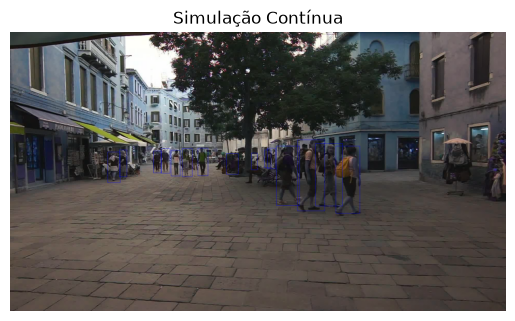

In [120]:
frames_with_bboxes_SDP = visualize_ground_truth_RGB(frames, dets_SDP)
plot_simulation_frames(frames_with_bboxes_SDP, delay=0)

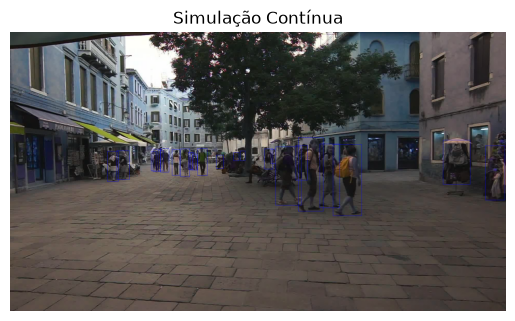

In [121]:
frames_with_bboxes_rcnn = visualize_ground_truth_RGB(frames, dets_rcnn)
plot_simulation_frames(frames_with_bboxes_rcnn)

In [74]:
dets_SDP_naive = [
    ', '.join(box[:-1].astype(int).astype(str))+f", {box[-1].astype(str)}" 
    for box in naive_tracker_shift(ground_truth_data=dets_SDP, threshold=0.5, max_age=10)
]

dets_rcnn_naive = [
    ', '.join(box[:-1].astype(int).astype(str))+f", {box[-1].astype(str)}" 
    for box in naive_tracker_shift(ground_truth_data=dets_rcnn, threshold=0.5, max_age=10)
]

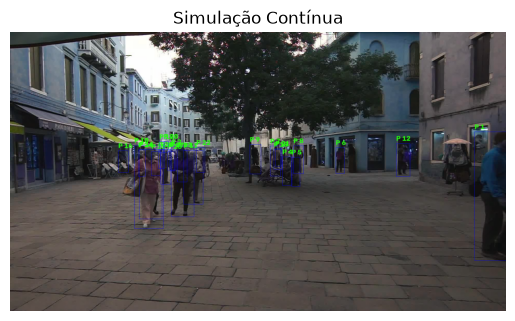

In [ ]:
frames_with_bboxes_SDP_naive = visualize_ground_truth_RGB(frames, dets_SDP_naive, put_id=True, fmt=lambda id: f"P {id}")
plot_simulation_frames(frames_with_bboxes_SDP_naive)

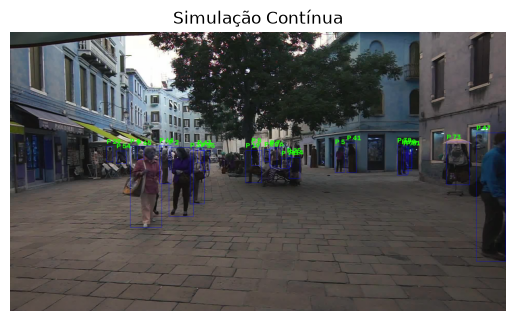

In [ ]:
frames_with_bboxes_rcnn_naive = visualize_ground_truth_RGB(frames, dets_rcnn_naive, put_id=True, fmt=lambda id: f"P {id}")
plot_simulation_frames(frames_with_bboxes_rcnn_naive)

In [75]:
metrics_1_3 = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_SDP_naive, threshold=0.5)
metrics_1_3

{'IDF1 Score': np.float64(0.34612839179351423),
 'ID Switches': 634,
 'Fragmentacoes': 1106,
 'Erro de Contagem de IDs': 485}

In [76]:
metrics_1_3 = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_rcnn_naive, threshold=0.5)
metrics_1_3

{'IDF1 Score': np.float64(0.2722906403940887),
 'ID Switches': 400,
 'Fragmentacoes': 551,
 'Erro de Contagem de IDs': 610}

### 4. Regras de Associação e Gestão de Trajetórias (Rastreador Ingênuo)

**1. Regra de Associação (Matching)**
A associação temporal entre objetos recorre à sobreposição espacial e a uma estratégia de otimização local, baseada nas seguintes regras:

* **Métrica de Custo:** Utiliza-se a **Interseção sobre a União (IoU)** entre as caixas delimitadoras (*bounding boxes*) das trajetórias ativas na memória e as novas detecções do quadro atual (\(t\)).
* **Estratégia de Resolução:** Aplica-se o algoritmo de **Matching Guloso (*Greedy Match*)**. O algoritmo procura iterativamente na matriz de IoU o valor global máximo, associando esse par (memória \(\leftrightarrow\) detecção). Após o pareamento, a respectiva linha e coluna são invalidadas, e o processo repete-se para os restantes candidatos até esgotar as opções.
* **Limiar Fixo (Corte):** Para evitar associações espúrias entre objetos distantes ou sobrepostos acidentalmente, a correspondência só é validada se o valor de IoU do par guloso for maior ou igual a um limiar fixo pré-definido (por padrão, $0.5$). Pareamentos abaixo deste valor são rejeitados.

**2. Gestão de Nascimento de Tracks**
Uma trajetória é considerada nova (nascimento) sempre que uma detecção no quadro \(t\) não consegue ser associada a nenhuma identidade pré-existente. Isto ocorre em duas situações:

* Não há sobreposição geométrica suficiente com nenhuma trajetória ativa (IoU inferior ao limiar).
* Todas as trajetórias ativas na vizinhança já foram "consumidas" pelo algoritmo guloso por possuírem maior IoU com outras detecções.

Quando o nascimento ocorre, o sistema atribui um **Identificador (ID) sequencial inédito** à detecção, inicializa o seu contador de idade (quadros sem observação) a $0$ e adiciona-a ao registro de memórias ativas.

**3. Gestão de Morte de Tracks (Memória e Tolerância)**
O rastreador não descarta imediatamente um objeto que deixe de ser detectado (por exemplo, devido a uma oclusão momentânea ou falha temporal do detector R-CNN). Existe um mecanismo de tolerância regulado pelo parâmetro \(K\) (`max_age`):

* **Envelhecimento:** Se uma trajetória presente na memória não for associada a nenhuma detecção no quadro \(t\), a sua última caixa delimitadora conhecida fica temporalmente **congelada** na mesma posição espacial, e o seu contador de idade é incrementado em \(+1\).
* **Rejuvenescimento:** Se em quadros seguintes o objeto voltar a ser detectado e o IoU com a caixa "fantasma" congelada for superior ao limiar, a associação é restabelecida. A posição espacial é atualizada com a nova detecção e a idade retorna a $0$.
* **Morte Definitiva:** Se uma trajetória acumular um número de quadros consecutivos sem observação igual ou superior ao limite de tolerância (\(K\)), o objeto é declarado **morto** e a trajetória é eliminada permanentemente da memória. Um reaparecimento futuro do mesmo objeto resultará num novo nascimento e, consequentemente, numa troca de identidade explícita (*ID Switch*).

In [77]:
def avaliar_todas_sequencias(dicionario_dados_brutos, limiares_map=np.arange(0.5, 0.96, 0.05)):
    """
    Processa todas as sequencias, roda o rastreador e extrai IDF1 e mAP reais.
    dicionario_dados_brutos = {'MOT17-04': {'gt': [...], 'preds': [...]}, ...}
    """
    resultados = {}
    
    for seq_name, dados in dicionario_dados_brutos.items():
        ground_truth = dados['gt']
        predicoes = dados['preds']
        
        # Metricas Temporais (O codigo que montamos anteriormente)
        traj_metrics = evaluate_trajectories(ground_truth, predicoes, threshold=0.5)
        
        # Calculo do mAP
        parts_t = np.array([list(map(float, x.split(','))) for x in ground_truth])
        parts_p = np.array([list(map(float, x.split(','))) for x in predicoes])
        
        num_frames = int(max(np.max(parts_t[:, 0]) if len(parts_t) > 0 else 0, 
                             np.max(parts_p[:, 0]) if len(parts_p) > 0 else 0))
        
        tp_total = {limiar: 0 for limiar in limiares_map}
        fp_total = {limiar: 0 for limiar in limiares_map}
        fn_total = {limiar: 0 for limiar in limiares_map}
        
        # Processamento Frame a Frame para Detecao (mAP)
        for f in range(1, num_frames + 1):
            frame_t = parts_t[parts_t[:, 0] == f]
            frame_p = parts_p[parts_p[:, 0] == f]
            
            if len(frame_t) == 0 and len(frame_p) == 0:
                continue
                
            iou_matrix = calculate_iou_matrix(frame_p, frame_t) if len(frame_p) > 0 and len(frame_t) > 0 else np.zeros((len(frame_p), len(frame_t)))
            
            # Avalia para cada limiar do mAP (0.50 a 0.95)
            for limiar in limiares_map:
                matches_iou, _ = greedy_match(iou_matrix, len(frame_p), len(frame_t))
                tp = (matches_iou >= limiar).sum()
                tp_total[limiar] += tp
                fp_total[limiar] += len(frame_p) - tp
                fn_total[limiar] += len(frame_t) - tp
                
        # Calcula a Average Precision (AP) para cada limiar e extrai a media (mAP)
        ap_por_limiar = []
        for limiar in limiares_map:
            tp = tp_total[limiar]
            fp = fp_total[limiar]
            fn = fn_total[limiar]
            ap = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
            ap_por_limiar.append(ap)
            
        map_final = np.mean(ap_por_limiar)
        
        # Densidade (Eixo de dificuldade)
        densidade_media = len(parts_t) / num_frames if num_frames > 0 else 0
        
        # Consolida os dados da sequencia
        num_trues = len(np.unique(parts_t[:, 1])) if len(parts_t) > 0 else 1
        num_preds = len(np.unique(parts_p[:, 1])) if len(parts_p) > 0 else 0
        
        resultados[seq_name] = {
            'mAP': map_final,
            'IDF1': traj_metrics['IDF1 Score'],
            'num_preds': num_preds,
            'num_trues': num_trues,
            'id_switches': traj_metrics['ID Switches'],
            'densidade': densidade_media
        }
        
    return resultados


def plotar_descolamento(resultados_sequencias, model: str):
    # Ordenacao estrita pelo eixo de dificuldade (Densidade)
    sequencias_ordenadas = sorted(resultados_sequencias.items(), key=lambda x: x[1]['densidade'])
    
    nomes_seqs = [seq[0] for seq in sequencias_ordenadas]
    map_vals = [seq[1]['mAP'] for seq in sequencias_ordenadas]
    idf1_vals = [seq[1]['IDF1'] for seq in sequencias_ordenadas]
    
    # Razoes para quantificar o fracasso
    razao_ids = [seq[1]['num_preds'] / seq[1]['num_trues'] for seq in sequencias_ordenadas]
    switches_por_id_real = [seq[1]['id_switches'] / seq[1]['num_trues'] for seq in sequencias_ordenadas]

    # Estrutura de duplo painel
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f'{model} - Quantificação do Fracasso: O Descolamento do Rastreador Ingénuo', fontsize=14, fontweight='bold')

    # Painel 1: mAP vs IDF1
    ax1.plot(nomes_seqs, map_vals, marker='o', color='royalblue', linewidth=2, label='mAP (Deteção)')
    ax1.plot(nomes_seqs, idf1_vals, marker='s', color='darkorange', linewidth=2, label='IDF1 (Trajetória)')
    ax1.set_ylabel('Pontuação', fontsize=11)
    ax1.set_title('Desempenho Geral (Deteção vs Associação)', fontsize=12)
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='lower left')

    # Painel 2: Explosao de IDs e Switches
    ax2.plot(nomes_seqs, razao_ids, marker='^', color='firebrick', linewidth=2, label='IDs Previstos / IDs Verdadeiros')
    ax2.plot(nomes_seqs, switches_por_id_real, marker='D', color='purple', linewidth=2, label='ID Switches / ID Verdadeiro')
    ax2.axhline(y=1.0, color='gray', linestyle=':', label='Razão Ideal (1.0 = Sem Fragmentação/Switches)')
    ax2.set_xlabel('Sequências de Vídeo (Dificuldade Crescente → Pessoas por Quadro)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Taxa / Multiplicador', fontsize=11)
    ax2.set_title('Descolamento da Identidade', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

In [78]:
# Estrutura os dados para a funcao
eval_SDP = {
    name: {"gt": ground_truth_SDP_by_video[name], "preds": dets_SDP_by_video[name]}
    for name in ground_truth_SDP_by_video.keys()
}

eval_rcnn = {
    name: {"gt": ground_truth_SDP_by_video[name], "preds": dets_rcnn_by_video[name]}
    for name in ground_truth_SDP_by_video.keys()
}

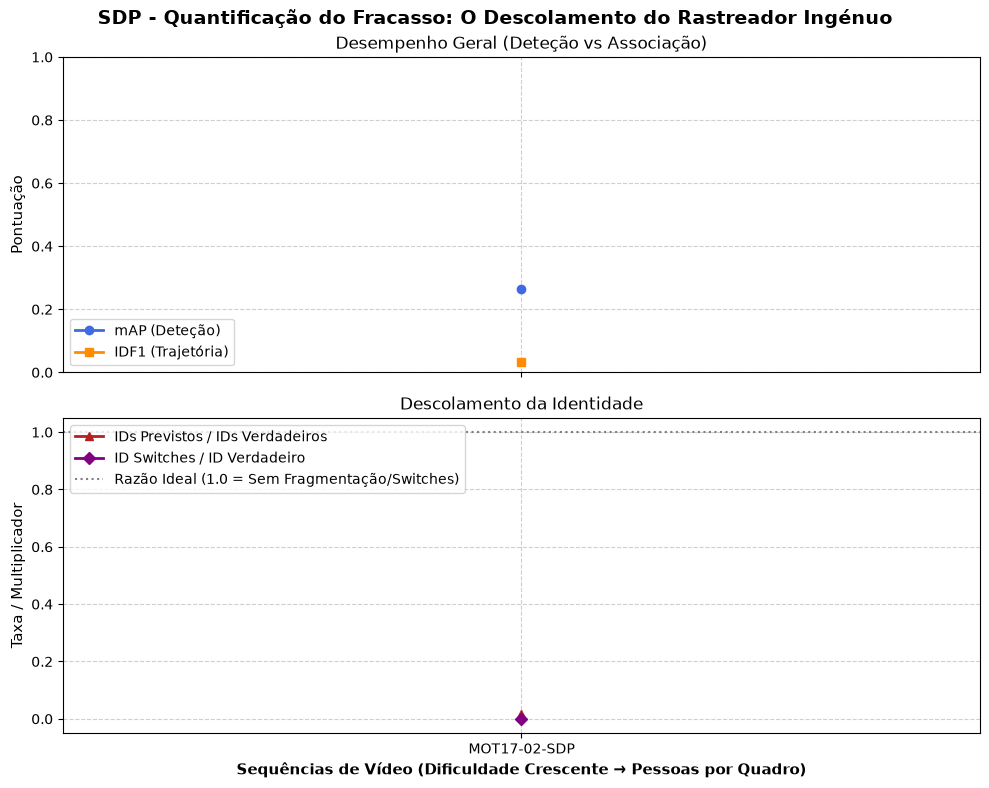

In [79]:
resultados_SDP = avaliar_todas_sequencias(eval_SDP)
plotar_descolamento(resultados_SDP, model="SDP")

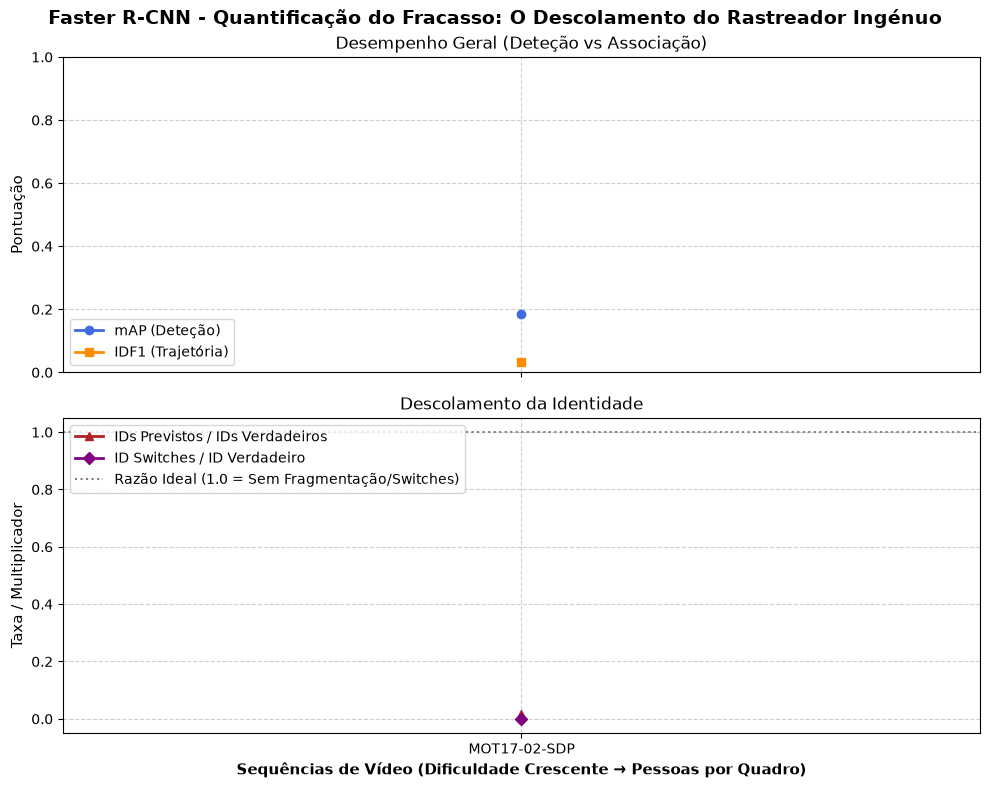

In [80]:
resultados_rcnn = avaliar_todas_sequencias(eval_rcnn)
plotar_descolamento(resultados_rcnn, model="Faster R-CNN")

---

# Parte 2

In [28]:
import torch

def extrair_trajetorias_mot17(ground_truth_list, min_len=8):
    """
    Lê o ground_truth do MOT17 e agrupa as caixas [x, y, w, h] por ID real.
    Ignora trajetórias curtas que não preencham a janela T do BPTT.
    """
    trajetorias = {}
    for linha in ground_truth_list:
        parts = linha.split(',')
        obj_id = int(float(parts[1]))
        x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
        
        if obj_id not in trajetorias:
            trajetorias[obj_id] = []
        trajetorias[obj_id].append([x, y, w, h])
        
    return [torch.tensor(traj, dtype=torch.float32) for traj in trajetorias.values() if len(traj) >= min_len]

In [46]:
print("--- PREPARANDO DADOS DE TREINO MISTURADOS ---")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_real = BBoxTrackerGRU(input_size=4, hidden_size=64).to(device)
criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.Adam(modelo_real.parameters(), lr=0.002) # Taxa ajustada para dados aleatórios

T = 8
img_h, img_w = frames_by_video[video_selected][0].shape[:2]
videos_treino = [v for v in ground_truth_SDP_by_video.keys() if v != video_selected]

todas_entradas = []
todos_alvos = []

# 1. Extração e Agrupamento
for seq_name in videos_treino:
    gt_video = ground_truth_SDP_by_video[seq_name]
    
    h_real, w_real = frames_by_video[seq_name][0].shape[:2]
    fator_norm = torch.tensor([w_real, h_real, w_real, h_real], dtype=torch.float32)
    
    trajetorias_pessoas = extrair_trajetorias_mot17(gt_video, min_len=T + 1)
    
    for traj_tensor in trajetorias_pessoas:
        if traj_tensor.size(0) <= T: continue
        
        inputs_batch, targets_batch = preparar_janelas_treino(traj_tensor, T)
        
        # Normaliza logo na extração
        inputs_batch = inputs_batch / fator_norm
        targets_batch = targets_batch / fator_norm
        
        todas_entradas.append(inputs_batch)
        todos_alvos.append(targets_batch)

# 2. Concatenação no Megatensor
X_treino = torch.cat(todas_entradas, dim=0)
Y_treino = torch.cat(todos_alvos, dim=0)

num_amostras = X_treino.size(0)
tamanho_batch = 128
print(f"Total de janelas de treino misturadas: {num_amostras}")

# 3. Treino Aleatório (Shuffled)
print("Iniciando otimização...")
for epoca in range(40):
    modelo_real.train()
    
    # Embaralha os índices a cada época para garantir generalização
    indices = torch.randperm(num_amostras)
    erro_acumulado = 0.0
    lotes_processados = 0
    
    for i in range(0, num_amostras, tamanho_batch):
        idx_batch = indices[i:i+tamanho_batch]
        
        x_batch = X_treino[idx_batch].to(device)
        y_batch = Y_treino[idx_batch].to(device)
        
        estado_oculto_zerado = modelo_real.init_hidden(batch_size=x_batch.size(0), device=device)
        optimizer.zero_grad()
        
        caixas_previstas, _ = modelo_real(x_batch, estado_oculto_zerado)
        loss = criterion(caixas_previstas, y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(modelo_real.parameters(), max_norm=1.0)
        optimizer.step()
        
        erro_acumulado += loss.item()
        lotes_processados += 1
        
    if epoca % 5 == 0:
        print(f"Época {epoca:03d} | Erro Médio: {erro_acumulado / lotes_processados:.5f}")

--- PREPARANDO DADOS DE TREINO MISTURADOS ---
Total de janelas de treino misturadas: 677
Iniciando otimização...
Época 000 | Erro Médio: 0.03569
Época 005 | Erro Médio: 0.00405
Época 010 | Erro Médio: 0.00054
Época 015 | Erro Médio: 0.00013
Época 020 | Erro Médio: 0.00005
Época 025 | Erro Médio: 0.00004
Época 030 | Erro Médio: 0.00004
Época 035 | Erro Médio: 0.00003


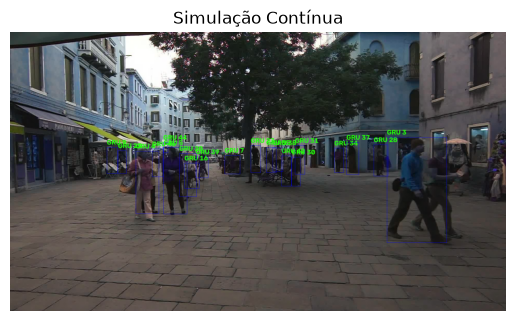

In [ ]:
print("\n--- TESTANDO O MODELO NO VÍDEO DE VALIDAÇÃO ---")

# Coloca em modo de inferência (desliga gradientes)
modelo_real.eval()

# Recuperamos os dados cru do vídeo de teste isolado
frames_validacao = frames_by_video[video_selected]
ground_truth_SDP = ground_truth_SDP_by_video[video_selected]
dets_SDP = dets_SDP_by_video[video_selected]

# Descobre a resolução real exclusivamente para este vídeo de validação
img_h, img_w = frames_validacao[0].shape[:2]

# Roda o rastreador GRU (Inteligente)
dets_SDP_gru = [
    ', '.join(box[:-1].astype(float).astype(int).astype(str)) + f", {box[-1]}" 
    for box in gru_tracker_shift(
        ground_truth_data=dets_SDP, 
        model=modelo_real, 
        device=device, 
        img_w=img_w, 
        img_h=img_h, 
        threshold=0.3, # Abaixado para tolerar o erro da rede
        max_age=3,     # Fantasmas morrem mais rápido
        T=8
    )
]

# Roda o rastreador GRU para as detecções do Faster R-CNN (Criadas na sua Parte 1)
dets_rcnn_gru = [
    ', '.join(box[:-1].astype(float).astype(int).astype(str)) + f", {box[-1]}" 
    for box in gru_tracker_shift(ground_truth_data=dets_rcnn, model=modelo_real, device=device, img_w=img_w, img_h=img_h, threshold=0.5, max_age=10)
]

# Avalia as métricas globais comparando com o modelo Ingênuo da Parte 1
metrics_SDP_naive = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_SDP_naive, threshold=0.5)
metrics_SDP_gru   = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_SDP_gru, threshold=0.5)

print("\n=== COMPARAÇÃO FINAL SDP ===")
print("Rastreador Ingênuo:", metrics_SDP_naive)
print("Rastreador Inteligente (GRU):", metrics_SDP_gru)

# Mostra a inferência visual do rastreamento ocorrendo em tempo real
frames_with_bboxes_gru = visualize_ground_truth_RGB(frames_validacao, dets_SDP_gru, put_id=True, fmt=lambda id: f"GRU {id}")
plot_simulation_frames(frames_with_bboxes_gru)

---

# Parte 3

In [81]:
def det_to_str(dets):
    return [
        ", ".join([
            *d[:-1].astype(int).astype(str),
            str(d[-1])
        ])
        for d in dets
    ]

In [86]:
import torch.nn as nn
import torch.optim as optim

class BBoxTrackerRNN(nn.Module):
    def __init__(self, rnn_type='GRU', input_size=4, hidden_size=64):
        super().__init__()
        self.rnn_type = rnn_type
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
            
        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, x, hidden=None):
        out, hidden = self.rnn(x, hidden)
        return self.fc(out[:, -1, :]), hidden


def treinar_modelo(modelo, ground_truth_limpo, device, epochs=80, T=8):
    dets = np.array([list(map(float, x.split(','))) for x in ground_truth_limpo])
    ids_unicos = np.unique(dets[:, 1])
    
    X_train, Y_train = [], []
    for uid in ids_unicos:
        traj = dets[dets[:, 1] == uid]
        if len(traj) <= T: continue
        
        coords = traj[:, 2:6].copy()
        # Normalização
        coords[:, 0] /= 1920.0
        coords[:, 1] /= 1080.0
        coords[:, 2] /= 1920.0
        coords[:, 3] /= 1080.0
        
        # BPTT Truncado: Sequência de tamanho exato T, para prever T+1
        for i in range(len(coords) - T):
            X_train.append(coords[i:i+T]) 
            Y_train.append(coords[i+T])   
            
    if not X_train: return modelo
    
    X_tensor = torch.tensor(np.array(X_train), dtype=torch.float32).to(device)
    Y_tensor = torch.tensor(np.array(Y_train), dtype=torch.float32).to(device)
    
    optimizer = optim.Adam(modelo.parameters(), lr=0.01) # Aumentei ligeiramente o LR
    criterion = nn.SmoothL1Loss()
    
    modelo.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred, _ = modelo(X_tensor) # Modelo processa os T passos e devolve o último
        loss = criterion(pred, Y_tensor)
        loss.backward()
        optimizer.step()
        
    return modelo


def gru_tracker_shift(ground_truth_data, model, device, img_w, img_h, threshold=0.3, max_age=3, min_hits=2, T=8):
    detections = np.array([list(map(float, x.split(','))) for x in ground_truth_data])
    if len(detections) == 0: return []
    num_frames = int(detections[-1, 0])
    
    tracked_results = []
    next_new_id = 1 
    active_tracks = {}
    model.eval()
    
    for f in range(1, num_frames + 1):
        frame_t = detections[detections[:, 0] == f]
        active_ids = list(active_tracks.keys())
        predicted_matrix = []
        
        # --- PASSO 1: PREVISÃO ONLINE (Estado mantido) ---
        for tid in active_ids:
            track = active_tracks[tid]
            
            # Pega APENAS a última observação (Passo t-1)
            last_obs = track['history'][-1]
            seq_input = torch.tensor([last_obs], dtype=torch.float32).unsqueeze(0).to(device)
            
            # Passa o estado oculto anterior para manter a memória (True RNN)
            with torch.no_grad():
                pred_norm, new_hidden = model(seq_input, track['hidden'])
                
            track['next_hidden'] = new_hidden # Guarda para atualizar se a track sobreviver
            
            pred_box = pred_norm.view(-1).cpu().numpy()
            x = pred_box[0] * img_w
            y = pred_box[1] * img_h
            w = track['bbox'][4] # Mantém escala
            h = track['bbox'][5]
            
            dummy_box = np.zeros(9)
            dummy_box[0:2] = [f, tid]
            dummy_box[2:6] = [x, y, w, h]
            dummy_box[6:9] = 1.0
            predicted_matrix.append(dummy_box)
             
        predicted_matrix = np.array(predicted_matrix) if len(predicted_matrix) > 0 else np.zeros((0, 9))
        
        # --- PASSO 2: MATCHING ---
        if len(predicted_matrix) > 0 and len(frame_t) > 0:
            iou_matrix = calculate_iou_matrix(predicted_matrix, frame_t)
            matches_iou, matches = greedy_match(iou_matrix, len(predicted_matrix), len(frame_t))
        else:
            matches_iou, matches = [0]*len(predicted_matrix), [None]*len(predicted_matrix)
            
        matched_current_to_memory = {}
        matched_memory_indices = set()
        
        for p_idx in range(len(predicted_matrix)):
            t_idx = matches[p_idx]
            if t_idx is not None and matches_iou[p_idx] >= threshold:
                matched_current_to_memory[int(t_idx)] = p_idx
                matched_memory_indices.add(p_idx)
                
        # --- PASSO 3: ATUALIZAÇÃO ---
        for t_idx in range(len(frame_t)):
            res = frame_t[t_idx].copy()
            norm_obs = [res[2]/img_w, res[3]/img_h, res[4]/img_w, res[5]/img_h]
            
            if t_idx in matched_current_to_memory:
                p_idx = matched_current_to_memory[t_idx]
                track_id = active_ids[p_idx]
                
                res[1] = track_id
                active_tracks[track_id]['bbox'] = res
                active_tracks[track_id]['history'].append(norm_obs)
                active_tracks[track_id]['hidden'] = active_tracks[track_id]['next_hidden'] # Atualiza Memória
                active_tracks[track_id]['age'] = 0
                active_tracks[track_id]['hits'] += 1
            else:
                track_id = next_new_id
                next_new_id += 1
                res[1] = track_id
                
                active_tracks[track_id] = {
                    'bbox': res, 'age': 0, 'history': [norm_obs], 'hits': 1,
                    'hidden': None # Nasce com memória vazia
                }
                
            if active_tracks[res[1]]['hits'] >= min_hits:
                tracked_results.append(res)
            
        # --- PASSO 4: OCLUSÃO E MORTE (A RNN Roda no Escuro) ---
        tracks_to_delete = []
        for p_idx, track_id in enumerate(active_ids):
            if p_idx not in matched_memory_indices:
                active_tracks[track_id]['age'] += 1
                
                if active_tracks[track_id]['age'] < max_age:
                    fake_res = predicted_matrix[p_idx].copy()
                    active_tracks[track_id]['bbox'] = fake_res
                    
                    # Oclusão: A previsão da rede torna-se a nova observação
                    norm_fake = [fake_res[2]/img_w, fake_res[3]/img_h, fake_res[4]/img_w, fake_res[5]/img_h]
                    active_tracks[track_id]['history'].append(norm_fake)
                    active_tracks[track_id]['hidden'] = active_tracks[track_id]['next_hidden'] # Memória avança
                    
                    if active_tracks[track_id]['hits'] >= min_hits:
                        tracked_results.append(fake_res)
                else:
                    tracks_to_delete.append(track_id)
                    
        for tid in tracks_to_delete:
            del active_tracks[tid]

    return np.array(tracked_results)



def rodar_ablacao_eixo1(ground_truth_limpo, device, img_w=1920, img_h=1080):
    seeds = [23, 42, 24]
    modelos = ['RNN', 'LSTM', 'GRU']
    resultados = {}
    
    for rnn_type in modelos:
        print(f"\n--- Treinando e Testando: {rnn_type} ---")
        idf1_scores = []
        
        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)
            
            # Instancia
            model = BBoxTrackerRNN(rnn_type=rnn_type, input_size=4, hidden_size=64).to(device)
            model = treinar_modelo(model, ground_truth_limpo, device, epochs=50, T=8)

            tracks_geradas = gru_tracker_shift(ground_truth_limpo, model, device, img_w, img_h, threshold=0.3, max_age=3, min_hits=2, T=8)
            tracks_geradas = det_to_str(tracks_geradas)
            
            if len(tracks_geradas) > 0:
                traj_metrics = evaluate_trajectories(ground_truth_limpo, tracks_geradas, threshold=0.5)
                idf1_scores.append(traj_metrics['IDF1 Score'])
            else:
                idf1_scores.append(0.0)
                
            print(f"Seed {seed}: IDF1 = {idf1_scores[-1]:.4f}")
            
        resultados[rnn_type] = {
            'IDF1_mean': np.mean(idf1_scores),
            'IDF1_std': np.std(idf1_scores)
        }
        
    return resultados

In [87]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LARGURA_VIDEO = 1920
ALTURA_VIDEO = 1080

# Executar a ablação do Eixo 1
resultados_finais_eixo1 = rodar_ablacao_eixo1(
    ground_truth_limpo=ground_truth_SDP, 
    device=device, 
    img_w=LARGURA_VIDEO, 
    img_h=ALTURA_VIDEO
)

print("\n" + "="*50)
print("RESULTADOS FINAIS - EIXO 1 (Média ± Desvio Padrão)")
print("="*50)
for modelo, res in resultados_finais_eixo1.items():
    print(f"Modelo {modelo:5s} | IDF1: {res['IDF1_mean']:.4f} ± {res['IDF1_std']:.4f}")


--- Treinando e Testando: RNN ---
Seed 23: IDF1 = 0.0144
Seed 42: IDF1 = 0.0081
Seed 24: IDF1 = 0.0445

--- Treinando e Testando: LSTM ---
Seed 23: IDF1 = 0.0420
Seed 42: IDF1 = 0.0598
Seed 24: IDF1 = 0.0460

--- Treinando e Testando: GRU ---
Seed 23: IDF1 = 0.1337
Seed 42: IDF1 = 0.2161
Seed 24: IDF1 = 0.1470

RESULTADOS FINAIS - EIXO 1 (Média ± Desvio Padrão)
Modelo RNN   | IDF1: 0.0223 ± 0.0159
Modelo LSTM  | IDF1: 0.0493 ± 0.0076
Modelo GRU   | IDF1: 0.1656 ± 0.0361


In [88]:
def rodar_ablacao_comprimento_janela(ground_truth_limpo, device, img_w=1920, img_h=1080):
    seeds = [23, 42, 24]
    modelos = ['RNN', 'LSTM', 'GRU']
    janelas_T = [4, 8, 16, 32]
    
    resultados_T = {modelo: [] for modelo in modelos}
    
    for modelo in modelos:
        print(f"\n" + "="*40)
        print(f"Testando a quebra do modelo: {modelo}")
        print("="*40)
        
        for T in janelas_T:
            idf1_scores = []
            for seed in seeds:
                torch.manual_seed(seed)
                np.random.seed(seed)
                
                net = BBoxTrackerRNN(rnn_type=modelo, input_size=4, hidden_size=64).to(device)
                
                # Treina com o T especifico
                net = treinar_modelo(net, ground_truth_limpo, device, epochs=50, T=T)
                
                # Testa com o T especifico
                tracks = gru_tracker_shift(
                    ground_truth_limpo, net, device, img_w, img_h, 
                    threshold=0.3, max_age=3, min_hits=2, T=T
                )
                tracks = det_to_str(tracks)
                
                if len(tracks) > 0:
                    metrica = evaluate_trajectories(ground_truth_limpo, tracks, threshold=0.5)
                    idf1_scores.append(metrica['IDF1 Score'])
                else:
                    idf1_scores.append(0.0)
                    
            media_idf1 = np.mean(idf1_scores)
            resultados_T[modelo].append(media_idf1)
            print(f" -> Janela T={T:2d} | IDF1 Médio: {media_idf1:.4f}")
            
    return resultados_T, janelas_T

In [89]:
res_janelas, lista_T = rodar_ablacao_comprimento_janela(ground_truth_SDP, device)


Testando a quebra do modelo: RNN
 -> Janela T= 4 | IDF1 Médio: 0.0131
 -> Janela T= 8 | IDF1 Médio: 0.0223
 -> Janela T=16 | IDF1 Médio: 0.1393
 -> Janela T=32 | IDF1 Médio: 0.0828

Testando a quebra do modelo: LSTM
 -> Janela T= 4 | IDF1 Médio: 0.0084
 -> Janela T= 8 | IDF1 Médio: 0.0493
 -> Janela T=16 | IDF1 Médio: 0.1125
 -> Janela T=32 | IDF1 Médio: 0.1100

Testando a quebra do modelo: GRU
 -> Janela T= 4 | IDF1 Médio: 0.0328
 -> Janela T= 8 | IDF1 Médio: 0.1656
 -> Janela T=16 | IDF1 Médio: 0.2757
 -> Janela T=32 | IDF1 Médio: 0.2427


---

# Parte 5

In [ ]:
def degradar_deteccoes(deteccoes_originais, p_drop, noise_std, num_fps, img_w=1920, img_h=1080):
    """
    Injeta falhas no detector: 
    - Descarta p_drop% das caixas
    - Adiciona ruido Gaussiano proporcional ao tamanho da caixa (noise_std)
    - Injeta num_fps caixas fantasmas por quadro
    """
    if isinstance(deteccoes_originais[0], str):
        dets = np.array([list(map(float, x.split(','))) for x in deteccoes_originais])
    else:
        dets = np.array(deteccoes_originais)
        
    frames = np.unique(dets[:, 0])
    deteccoes_degradadas = []
    fake_id = 90000 # IDs altos para Falsos Positivos
    
    for f in frames:
        frame_dets = dets[dets[:, 0] == f]
        
        # Drop e Ruido nas reais
        for det in frame_dets:
            if random.random() < p_drop:
                continue # Falso Negativo -> Descarte
                
            nova_det = det.copy()
            w, h = nova_det[4], nova_det[5]
            
            # Adiciona ruido espacial baseado na escala da pessoa
            nova_det[2] += np.random.normal(0, noise_std * w)
            nova_det[3] += np.random.normal(0, noise_std * h)
            nova_det[4] += np.random.normal(0, noise_std * w)
            nova_det[5] += np.random.normal(0, noise_std * h)
            
            # Impede dimensoes negativas
            nova_det[4] = max(10, nova_det[4])
            nova_det[5] = max(10, nova_det[5])
            
            deteccoes_degradadas.append(nova_det)
            
        # Injecao de Falsos Positivos Aleatorios
        for _ in range(num_fps):
            w_fp = random.uniform(30, 100)
            h_fp = random.uniform(100, 300)
            x_fp = random.uniform(0, img_w - w_fp)
            y_fp = random.uniform(0, img_h - h_fp)
            
            fake_det = [f, fake_id, x_fp, y_fp, w_fp, h_fp, random.uniform(0.5, 1.0), 1, 1.0]
            deteccoes_degradadas.append(fake_det)
            fake_id += 1
            
    return np.array(deteccoes_degradadas)

In [25]:
def rodar_degradacao_detector(ground_truth, dets_limpo, niveis, tracker=naive_tracker_shift, **kwargs):
    dicionario_experiencias = {}
    
    for nome_nivel, conf in niveis.items():
        print(f"Gerando dados para: {nome_nivel}...")
        
        # Estraga o detector
        dets_degradadas = degradar_deteccoes(
            dets_limpo, 
            p_drop=conf['drop'], 
            noise_std=conf['ruido'], 
            num_fps=conf['fps']
        )
        dets_degradadas = det_to_str(dets_degradadas)
        
        # Roda o rastreador
        preds_do_rastreador = tracker(dets_degradadas, **kwargs)
        preds_do_rastreador = det_to_str(preds_do_rastreador)
        
        dicionario_experiencias[nome_nivel] = {
            'gt': ground_truth, 
            'preds': preds_do_rastreador
        }
        
    print("Avaliando todas as configurações de degradação juntas...")
    
    
    resultados_finais = avaliar_todas_sequencias(dicionario_experiencias)
    
    # Imprime os resultados formatados
    for nivel, metrica in resultados_finais.items():
        print(f"{nivel:12s} -> mAP: {metrica['mAP']:.4f} | IDF1: {metrica['IDF1']:.4f}")
        
    return resultados_finais

In [ ]:
niveis = {
    '1_Limpo': {'drop': 0.00, 'ruido': 0.00, 'fps': 0},
    '2_Leve': {'drop': 0.10, 'ruido': 0.05, 'fps': 2},
    '3_Moderado': {'drop': 0.25, 'ruido': 0.10, 'fps': 5},
    '4_Severo': {'drop': 0.50, 'ruido': 0.20, 'fps': 10}
}

resultados_05 = rodar_degradacao_detector(ground_truth_SDP, dets_SDP, niveis, tracker=naive_tracker_shift, threshold=0.5, max_age=10)

Gerando dados para: 1_Limpo...
Gerando dados para: 2_Leve...
Gerando dados para: 3_Moderado...
Gerando dados para: 4_Severo...
Avaliando todas as configurações de degradação juntas...
1_Limpo      -> mAP: 0.3290 | IDF1: 0.6604
2_Leve       -> mAP: 0.2370 | IDF1: 0.5442
3_Moderado   -> mAP: 0.1125 | IDF1: 0.3159
4_Severo     -> mAP: 0.0314 | IDF1: 0.1098
